In [8]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

device = torch.accelerator.current_accelerator () .type if torch.accelerator.is_available () else "cpu"
print ( f"{device=}" )
print ( f"{torch.__version__=}" )

device='cuda'
torch.__version__='2.11.0+cu130'


## PyTorch Workflow:

I. Preparing and loading data into tensors
- training set (~60-80%)
- validation set (~10-20%)
- testing set (~10-20%)

II. Build a model
- Pick a loss function & optimizer
- Build a training loop

III. Fit the model to the data and make a prediction

IV. Evaluate the model (inference)

V. Improve the model through experimentation

VI. Save and reload the trained model

### I. Preparing and loading data into tensors

1. Get data into a numerical representation
2. Build a model to learn patterns in the numerical representation

Capital letter represents a matrix (2D) or a tensor. Small letter represents a scalar or a vector (1D).

Linear regression : $y = Xw + b$
- $X$ : macierz o wymiarach [d,1] (gdzie N to liczba próbek, a d to liczba cech)
- $w$ : wektor wag o wymiarach [d,1]
- Mnożenie $Xw$ daje wynik zgodny wymiarowo: [N,d] x [d,1] = [N,1]
- Otrzymujemy wektor wynikowy y o wymiarze [N,1] do którego dodawany jest wektor obciążenia b.

Jeśli równanie ma opisywać przejście przez sieć tylko jednej, pojedynczej obserwacji (wersja dla pojedynczej próbki), oznaczamy ją małą literą $x$ (jako wektor kolumnowy cech). Równanie przyjmuje wtedy postać : $y = w^T x + b$
- $w^T$ : transponowany wektor wag, który zmienia się z wektora kolumnowego [d,1] na wektor wierszowy [1,d]
- $x$ to wektor cech pojedynczej próbki o wymiarze [d,1]
- mnożenie [1,d] x [d,1] daje w wyniku skalar (pojedynczą liczbę) y.

Większość modeli i warstw w PyTorch (np. standardowa warstwa liniowa `nn.Linear`) kategorycznie wymaga, aby dane wejściowe $X$ były przynajmniej dwuwymiarowe. Standardowy format, jakiego oczekuje framework, to : [ wielkość_batcha , liczba_cech ] (ang. [ batch_size , features ] ). Przekazanie do modelu tensora `shape=torch.Size([50]`) spowoduje błąd, ponieważ PyTorch nie będzie wiedział, jak zinterpretować te dane (czy to jedna próbka z 50 cechami, czy 50 próbek z 1 cechą).
Dzięki .unsqueeze ( dim = 1 ) nasz shape=torch.Size([50, 1]), co mówi modelowi absolutnie jednoznacznie: "To jest macierz moich danych X. Mam w niej 50 osobnych obserwacji, a każda z nich jest opisana przez dokładnie 1 cechę". W ten sposób tensor jest przygotowany do poprawnego mnożenia macierzowego przez wagi modelu.

In [9]:
w = 0.7 ; b = 0.3 # weight , bias
start = 0 ; end = 1 ; step = 0.02

# Input tensor (matrix) of shape (n_samples, n_features) = (50, 1)
X = torch.arange ( start , end , step ) .unsqueeze ( dim = 1 ) ; print ( f"{X[:5]=} {X.shape=} {X.grad=} {X.is_leaf=}" )
# Output tensor (matrix) of shape (n_samples, n_outputs) = (50, 1)
y = w * X + b ; print ( f"{y[:5]=} {y.shape=} {y.grad=} {y.is_leaf=}" )

# Create a train / test split
train_split = int ( 0.8 * len ( X ) ) # 80%
X_train , y_train = X [ : train_split ] , y [ : train_split ]
X_test , y_test = X [ train_split : ] , y [ train_split : ]

def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    
    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})

X[:5]=tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800]]) X.shape=torch.Size([50, 1]) X.grad=None X.is_leaf=True
y[:5]=tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560]]) y.shape=torch.Size([50, 1]) y.grad=None y.is_leaf=True


### II. Build a model

1. Create linear regression model class
- create forward function
- create a learnable parameters

In [10]:
class LinearRegressionModel ( nn.Module ) :
    def __init__ ( self ) :
        super () .__init__ () # call the constructor of the parent class nn.Module
        self.w = nn.Parameter ( torch.randn ( 1 , requires_grad = True ) ) # create a learnable parameter w (weight) with initial random value 
        self.b = nn.Parameter ( torch.randn ( 1 , requires_grad = True ) ) # create a learnable parameter b (bias) with initial random value

    def forward ( self , x : torch.Tensor ) -> torch.Tensor : # define the forward pass of the model
        return self.w * x + self.b # pass the input through the linear layer and return the output

2. Define loss and optimizer
- a loss function:  measures how wrong your model is - as in, how far are its predictions off where they should be.
- an optimizers:    change the neural network weights in such a way that it reduces the loss function value.

y_preds=tensor([[1.4092],
        [1.4107],
        [1.4122],
        [1.4136],
        [1.4151],
        [1.4166],
        [1.4181],
        [1.4196],
        [1.4211],
        [1.4225]]) y_preds.grad_fn=None


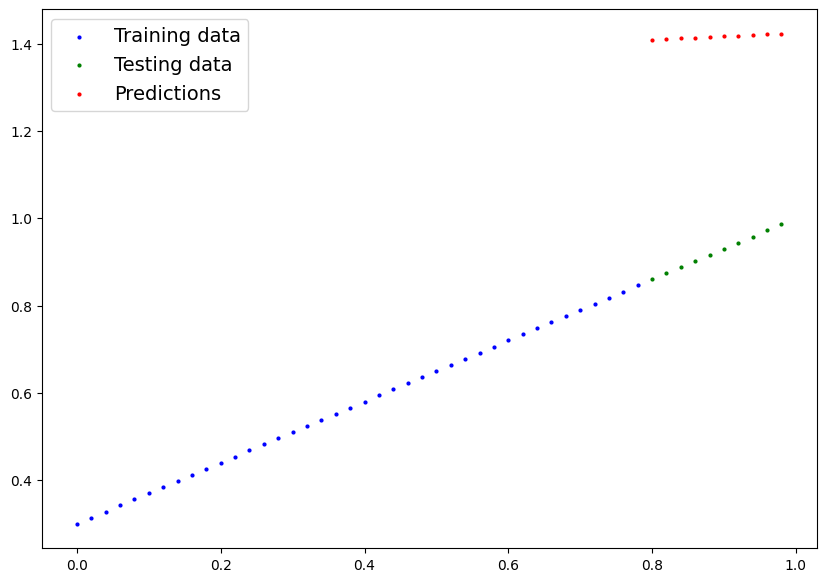

In [11]:
# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel ()

with torch.inference_mode () : # turn on inference mode (also known as evaluation mode) to speed up calculations and reduce memory usage
    y_preds = model_0 ( X_test ) # make predictions with the untrained model
print ( f"{y_preds=} {y_preds.grad_fn=}" )
plot_predictions ( predictions = y_preds )

loss_fn = nn.L1Loss () # create a loss function (also known as criterion) for regression problems
optimizer = torch.optim.SGD ( params = model_0.parameters () , lr = 0.01 ) # create an optimizer for the model's parameters with a learning rate of 0.


III. Training loop

Epoch: 0 | MAE Train Loss: 0.8057613372802734 | MAE Test Loss: 0.47939449548721313 
Epoch: 10 | MAE Train Loss: 0.6905515789985657 | MAE Test Loss: 0.34468457102775574 
Epoch: 20 | MAE Train Loss: 0.5753415822982788 | MAE Test Loss: 0.20997467637062073 
Epoch: 30 | MAE Train Loss: 0.4601317048072815 | MAE Test Loss: 0.07526475191116333 
Epoch: 40 | MAE Train Loss: 0.3449217975139618 | MAE Test Loss: 0.061698563396930695 
Epoch: 50 | MAE Train Loss: 0.25224512815475464 | MAE Test Loss: 0.1749654859304428 
Epoch: 60 | MAE Train Loss: 0.21044933795928955 | MAE Test Loss: 0.24603132903575897 
Epoch: 70 | MAE Train Loss: 0.19007083773612976 | MAE Test Loss: 0.2909746468067169 
Epoch: 80 | MAE Train Loss: 0.17859791219234467 | MAE Test Loss: 0.3188466429710388 
Epoch: 90 | MAE Train Loss: 0.17111654579639435 | MAE Test Loss: 0.3358455300331116 
Epoch: 100 | MAE Train Loss: 0.1658170223236084 | MAE Test Loss: 0.3456993103027344 
Epoch: 110 | MAE Train Loss: 0.1615968942642212 | MAE Test Loss:

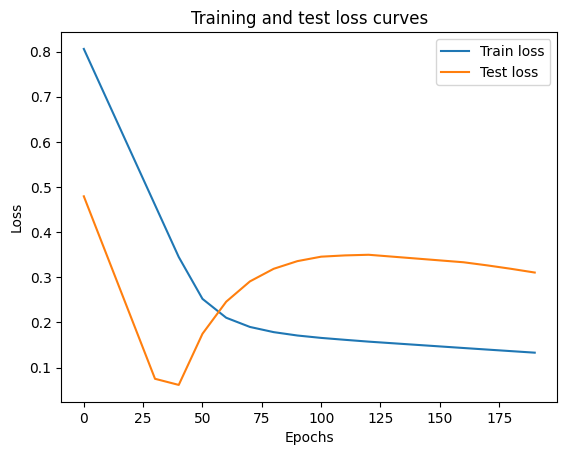

In [12]:
# Set the number of epochs (how many times the model will pass over the training data)
epochs = 200

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {w}, bias: {b}")

# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();